# let's plot the probability of beaching globally, then add circulation and wind data, then save a final figure

### This notebook plots sea surface height anomaly over the probability of beaching figure using sea surface height measurements by ssalto/duacs:
Those [ocean circulation] products were processed by SSALTO/DUACS and distributed by AVISO+ (https://www.aviso.altimetry.fr) with support from CNES. The Ssalto/Duacs altimeter products were produced and distributed by the Copernicus Marine and Environment Monitoring Service (CMEMS) http://www.marine.copernicus.eu. 

### This notebook plots 10m winds over the probability of beaching figure ERA5 monthly averaged data:

Hersbach et al., 2023 Hersbach, H., Bell, B., Berrisford, P., Biavati, G., Horányi, A., Muñoz Sabater, J., Nicolas, J., Peubey, C., Radu, R., Rozum, I., Schepers, D., Simmons, A., Soci, C., Dee, D., & Thépaut, J.-N. (2023). ERA5 monthly averaged data on single levels from 1940 to present [Dataset, Accessed on 2024-05-19]. Copernicus Climate Change Service (C3S) Climate Data Store (CDS). https://doi.org/10.24381/cds.f17050d7.

In [2]:
# set working directory
import os
os.chdir('/dat1/openonic/Drifters') # directory

In [3]:
# dependencies
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from tqdm import tqdm
import netCDF4 as nc

import scipy.interpolate as sci_int
import scipy.stats as sci_stats
import geopandas as gpd
import geodatasets
from matplotlib.colors import LinearSegmentedColormap

from scipy.ndimage import gaussian_filter,  generic_filter

/home/openonic/.conda/envs/drifter_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# set plotting text size parameters
plt.rcParams.update({
    'axes.titlesize': 30,
    'axes.labelsize': 24, 
    'xtick.labelsize': 18,  
    'ytick.labelsize': 18,  
    'legend.fontsize': 18, 
    'figure.titlesize': 28})

In [5]:
# load probability of beaching data
beach_undrogued = pd.read_csv('undrogued_beach.csv')
unbeach_undrogued = pd.read_csv('undrogued_unbeach.csv')

In [6]:
os.chdir('/home/openonic/global-drifter-program')

In [7]:
# get beached lats and lons
beach_undrogued_lats = np.array(beach_undrogued['lat'])
beach_undrogued_longs = np.array(beach_undrogued['lon'])

# get unbeached lats and lons
unbeach_undrogued_lats = np.array(unbeach_undrogued['lat'])
unbeach_undrogued_longs = np.array(unbeach_undrogued['lon'])

In [8]:
# let's use sci_stats.binned_statistic_2d to bin by lat/lon and count

# beached
n_lons, n_lats = 360, 180 # Define the number of grid cells
lon_bins = np.linspace(-180, 180, n_lons + 1)
lat_bins = np.linspace(-90, 90, n_lats + 1)

beach_undrogued_stat, x_edge, y_edge, binnumber = sci_stats.binned_statistic_2d(
    beach_undrogued_longs,beach_undrogued_lats,values=beach_undrogued['id'],
    statistic = 'count', bins = [lon_bins,lat_bins])

# unbeached
n_lons, n_lats = 360, 180 # Define the number of grid cells
lon_bins = np.linspace(-180, 180, n_lons + 1)
lat_bins = np.linspace(-90, 90, n_lats + 1)

unbeach_undrogued_stat, x_edge, y_edge, binnumber = sci_stats.binned_statistic_2d(
    unbeach_undrogued_longs,unbeach_undrogued_lats,values=unbeach_undrogued['id'],
    statistic = 'count', bins = [lon_bins,lat_bins])

In [9]:
def probability_of_beaching(beached_count, unbeached_count):
    probability = beached_count / (beached_count + unbeached_count)
    return probability

In [10]:
probability_undrogued = probability_of_beaching(beach_undrogued_stat, unbeach_undrogued_stat).T

# put into 'beach_prob' dataframe and remove data past -70 and 70 degrees lat:
beach_prob = pd.DataFrame(probability_undrogued)#.iloc[30:-30]
beach_prob_vals = beach_prob.values

/tmp/ipykernel_226982/3110105240.py:2: RuntimeWarning: invalid value encountered in divide
  probability = beached_count / (beached_count + unbeached_count)


In [11]:
probability_undrogued = probability_of_beaching(beach_undrogued_stat, unbeach_undrogued_stat).T

# put into 'beach_prob' dataframe and remove data past -70 and 70 degrees lat:
beach_prob = pd.DataFrame(probability_undrogued)#.iloc[30:-30]
beach_prob_vals = beach_prob.values

/tmp/ipykernel_226982/3110105240.py:2: RuntimeWarning: invalid value encountered in divide
  probability = beached_count / (beached_count + unbeached_count)


In [12]:
def nan_gaussian_filter(values, sigma):
    mask = np.isnan(values)
    values_filled = np.where(mask, np.nanmean(values), values)  # Replace NaNs with the mean of non-NaNs
    filtered = gaussian_filter(values_filled, sigma=sigma)
    filtered[mask] = np.nan  # Restore NaNs
    return filtered

# Apply the custom Gaussian filter
beach_prob_vals_filtered = nan_gaussian_filter(beach_prob_vals, sigma=0.5)

In [13]:
# define desired rows and desired cols
desired_rows = 360
desired_cols = 180
# define lat and lon
lats = np.linspace(-90,90,desired_cols)
lons = np.linspace(-180, 180, desired_rows)

In [14]:
os.chdir('/home/openonic/global-drifter-program/new')

ERROR 1: PROJ: proj_create_from_database: Open of /home/openonic/.conda/envs/drifter_env/share/proj failed


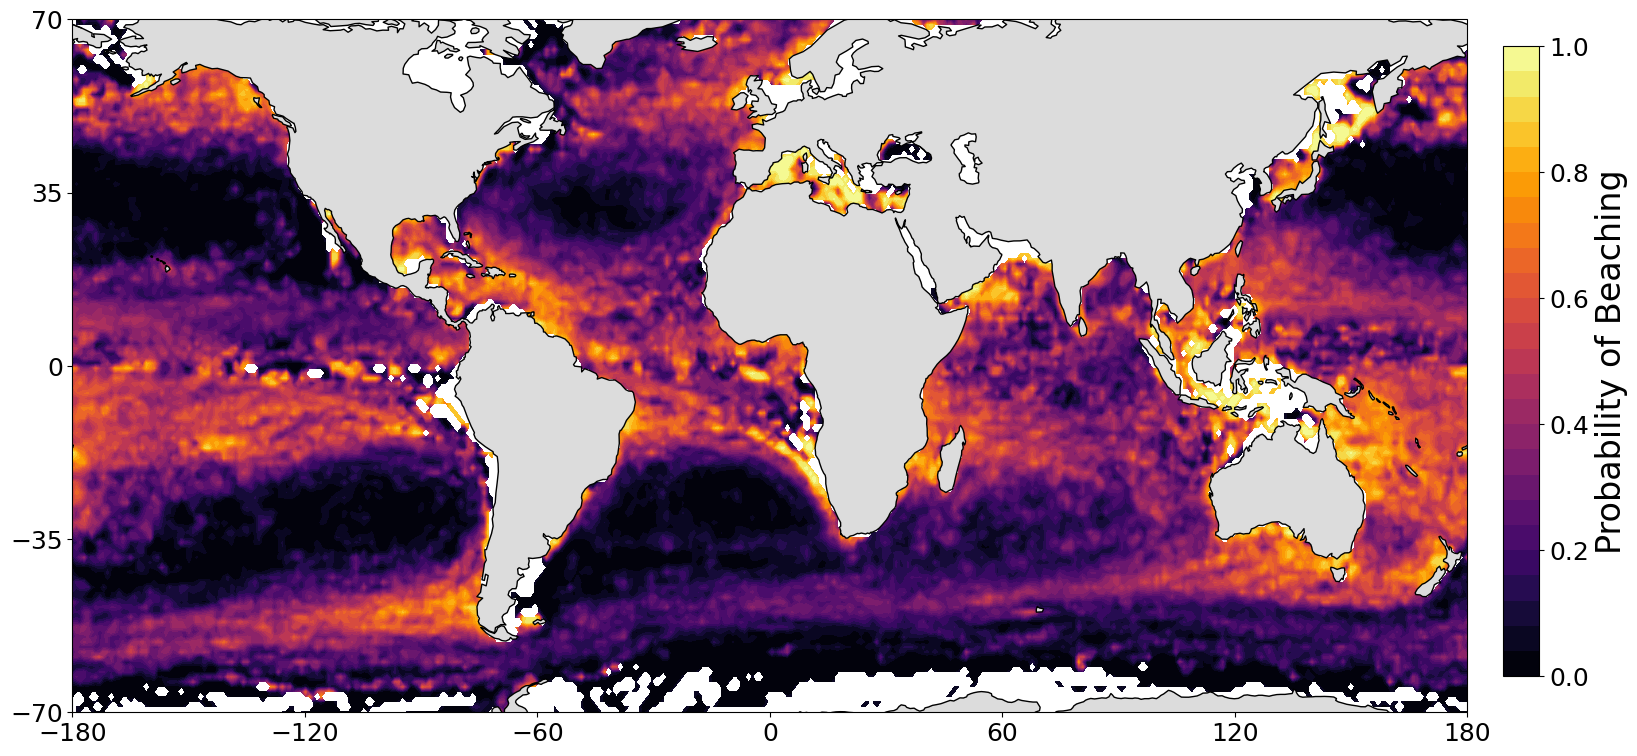

In [15]:
# Load world shapefile
world = gpd.read_file(geodatasets.data.naturalearth.land.path)
#land = world[world['continent'] != 'Antarctica']
#Antarctica = world[world['continent'] == 'Antarctica']


# visualize probability of beaching
fig, (ax1) = plt.subplots(1, 1, figsize=(18, 9),
                          subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)})

ax1.set_xticks([-180, -120, -60, 0, 60, 120, 180])
ax1.set_yticks([-70, -35, 0, 35, 70])


cmap = plt.get_cmap('inferno').copy()
ax1.set_extent([-180, 180, -70, 70], crs=ccrs.PlateCarree())
im1 = ax1.contourf(lons, lats, beach_prob_vals_filtered, cmap=cmap, transform=ccrs.PlateCarree(), 
                   vmin=0, vmax=1.0, levels = 24)


#ax1.set_title('Probability of Beaching')
#ax1.set_xlabel('Longitude')
#ax1.set_ylabel('Latitude')

world.plot(ax=ax1, color='gainsboro', edgecolor='none')
#Antarctica.plot(ax=ax1, color='gainsboro', edgecolor='none')
ax1.set_aspect('auto')

ax1.coastlines(color = 'black')

# Create a colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im1, cax=cbar_ax, label='Probability of Beaching')
cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
im1.set_clim(0, 1.0)  # This sets the color limits for the ScalarMappable

#plt.savefig('figs/probability_of_beaching.png', dpi=300)

# Show the plot
plt.show()

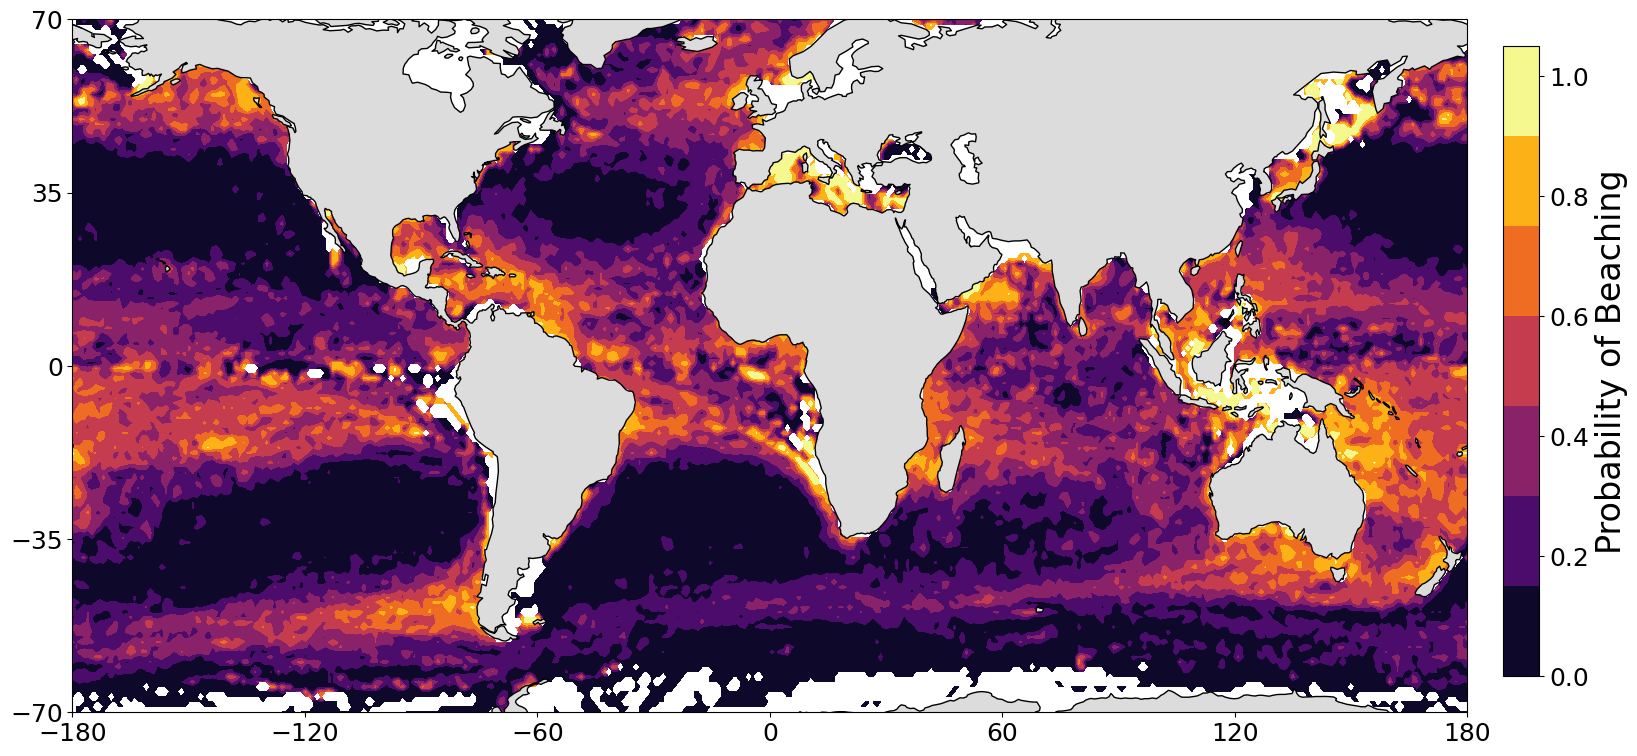

In [16]:
# Load world shapefile
world = gpd.read_file(geodatasets.data.naturalearth.land.path)
#land = world[world['continent'] != 'Antarctica']
#Antarctica = world[world['continent'] == 'Antarctica']


# visualize probability of beaching
fig, (ax1) = plt.subplots(1, 1, figsize=(18, 9),
                          subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)})

ax1.set_xticks([-180, -120, -60, 0, 60, 120, 180])
ax1.set_yticks([-70, -35, 0, 35, 70])


cmap = plt.get_cmap('inferno').copy()
ax1.set_extent([-180, 180, -70, 70], crs=ccrs.PlateCarree())
im1 = ax1.contourf(lons, lats, beach_prob_vals_filtered, cmap=cmap, transform=ccrs.PlateCarree(), 
                   vmin=0, vmax=1.0, levels = 6)


#ax1.set_title('Probability of Beaching')
#ax1.set_xlabel('Longitude')
#ax1.set_ylabel('Latitude')

world.plot(ax=ax1, color='gainsboro', edgecolor='none')
#Antarctica.plot(ax=ax1, color='gainsboro', edgecolor='none')
ax1.set_aspect('auto')

ax1.coastlines(color = 'black')

# Create a colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im1, cax=cbar_ax, label='Probability of Beaching')
cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
im1.set_clim(0, 1.0)  # This sets the color limits for the ScalarMappable

#plt.savefig('probability_of_beaching.png', dpi=300)

# Show the plot
plt.show()

In [17]:
os.chdir('/home/openonic/global-drifter-program')

In [18]:
ssh = nc.Dataset('data/ssh.nc')
# Extract the 'adt' variable, and its coordinates
adt_data = ssh.variables['adt'][:]
adt_lons = ssh.variables['longitude'][:]
adt_lats = ssh.variables['latitude'][:]

/tmp/ipykernel_226982/332400279.py:5: UserWarning: WARNING: valid_max not used since it
cannot be safely cast to variable data type
  adt_lats = ssh.variables['latitude'][:]


In [19]:
adt_data_flat = np.array(adt_data).flatten()

# Create longitude and latitude arrays that match the shape of adt_data
lon_points = adt_data.shape[2]  # Number of longitude points
lat_points = adt_data.shape[1]  # Number of latitude points

# Generate latitudes and longitudes that correspond to the grid of adt_data
adt_lons = np.linspace(-180, 180, lon_points)
adt_lats = np.linspace(-90, 90, lat_points)

# Use meshgrid to create full latitude and longitude arrays for each grid point
adt_lons_grid, adt_lats_grid = np.meshgrid(adt_lons, adt_lats)

# Flatten the grids to match adt_data_flat
adt_lons_flat = adt_lons_grid.flatten()
adt_lats_flat = adt_lats_grid.flatten()

# Define binning parameters
n_lons, n_lats = 360, 180
lon_bins = np.linspace(-180, 180, n_lons + 1)
lat_bins = np.linspace(-95, 85, n_lats + 1) # adjustment for vertical shift error

# Compute binned statistics
adt_stat, x_edge, y_edge, binnumber = sci_stats.binned_statistic_2d(
    adt_lons_flat, adt_lats_flat, adt_data_flat,
    statistic='mean', bins=[lon_bins, lat_bins]
)

# Shift `adt_stat` to center Atlantic
adt_stat = np.roll(adt_stat, shift=adt_stat.shape[0] // 2, axis=0)

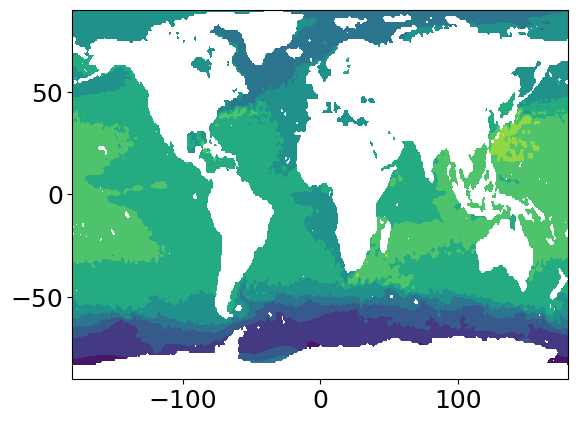

In [25]:
adt_stat_cont_remove = adt_stat.copy()
adt_stat_cont_remove[adt_stat < -2] = np.nan
adt_stat_filtered = nan_gaussian_filter(adt_stat_cont_remove, sigma=2)

# define desired rows and desired cols
desired_rows = 360
desired_cols = 180
# define lat and lon
lats = np.linspace(-90,90,desired_cols)
lons = np.linspace(-180, 180, desired_rows)
plt.contourf(lons, lats, adt_stat_cont_remove.T)

In [26]:
def lighten_colormap(cmap_name, factor=0.5):
    # Load the original colormap
    cmap = plt.cm.get_cmap(cmap_name)
    # Create a function to interpolate colors and make them lighter
    colors = cmap(np.linspace(0, 1, 256))
    lighter_colors = 1 - factor * (1 - colors[:, :3])  # Move colors toward white
    lighter_cmap = LinearSegmentedColormap.from_list(f"{cmap_name}_lighter", lighter_colors)
    return lighter_cmap
lighter_cividis = lighten_colormap('cividis')

/tmp/ipykernel_226982/1354519863.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)


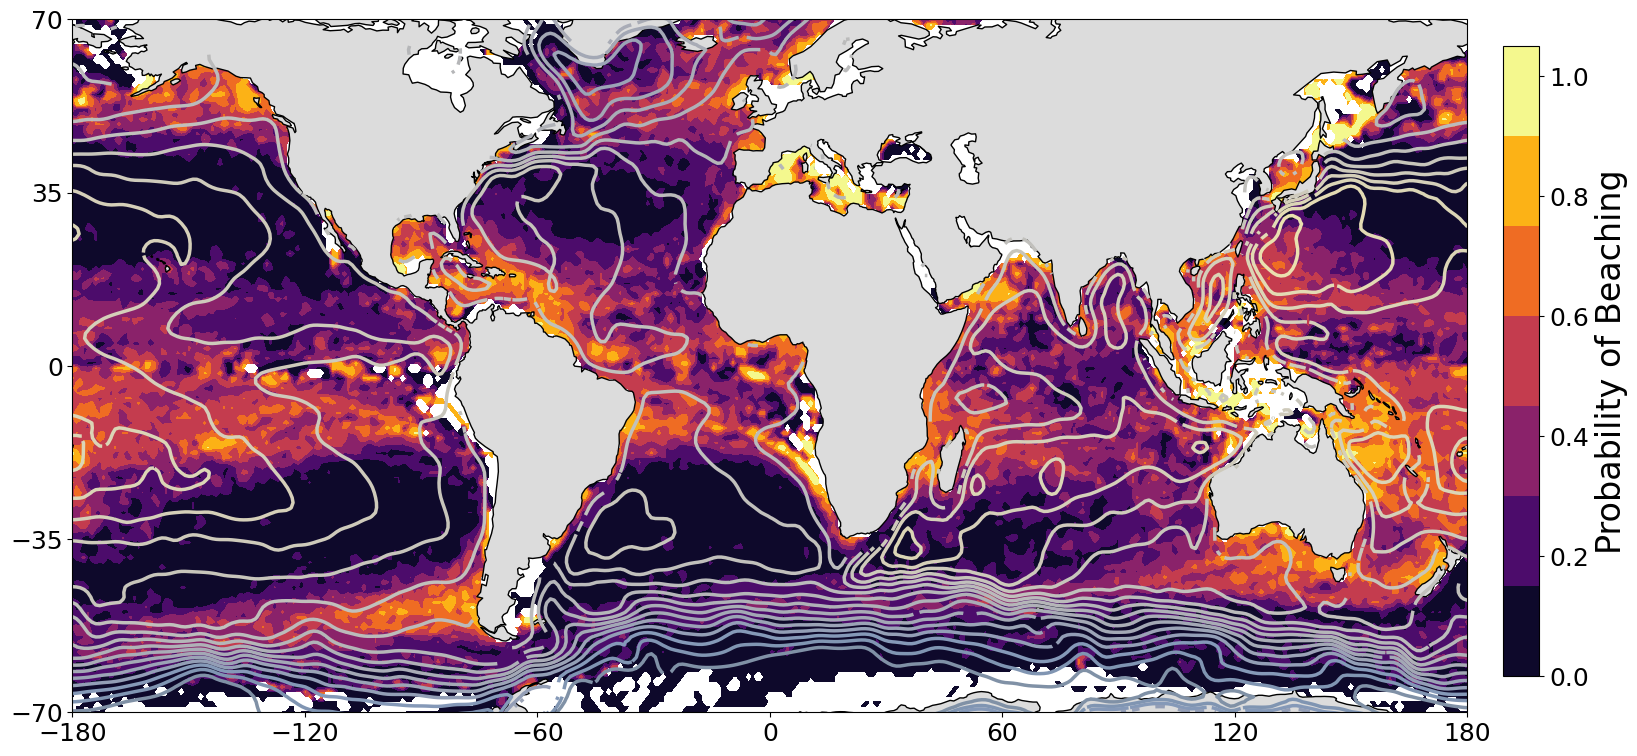

In [27]:
# Load world shapefile
world = gpd.read_file(geodatasets.data.naturalearth.land.path)

# visualize probability of beaching
fig, ax1 = plt.subplots(1, 1, figsize=(18, 9),
                          subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)})
ax1.set_xticks([-180, -120, -60, 0, 60, 120, 180])
ax1.set_yticks([-70, -35, 0, 35, 70])

cmap = plt.get_cmap('inferno').copy()
im1 = ax1.contourf(lons, lats, beach_prob_vals_filtered, cmap=cmap, 
                   transform=ccrs.PlateCarree(), vmin=0, vmax=1.0, levels=6)

ax1.set_extent([-180, 180, -70, 70], crs=ccrs.PlateCarree())

world.plot(ax=ax1, color='gainsboro', edgecolor='none')

ax1.coastlines(color='black')
ax1.set_aspect('auto')

# colorbar for probability of beaching
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im1, cax=cbar_ax, label='Probability of Beaching')
cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
im1.set_clim(0, 1.0)  # Sets the color limits for the ScalarMappable

# plot ssh contours
contour_levels = np.linspace(-1,2,20)#[-0.25, 0, 0.25, 0.5, 0.75, 1, 1.25, 1.5,1.7,1.8]
contour = ax1.contour(lons, lats, adt_stat_filtered.T, levels=contour_levels,
            cmap = lighter_cividis, linewidths = 2.5, vmin = -1, vmax = 2)


#plt.savefig('prob_beach_ssh.png', dpi=300)
plt.show()

In [28]:
os.chdir('/dat1/openonic/Drifters')

In [30]:
# load u and v coastal norm component CSVs:
u_df = pd.read_csv('u_df.csv')
v_df = pd.read_csv('v_df.csv')

# load wind CSV:
avg_u_winds = pd.read_csv('avg_u_winds.csv')
avg_v_winds = pd.read_csv('avg_v_winds.csv')

In [31]:
def df_aggregation_by_factor_8(df):
    # keep original df unaffected
    working_df = df.copy()

    # initialize row mean:
    row_means = []
    
    # for each odd row    
    for i in tqdm(range(0, len(working_df), 2)):

        # initialize column mean:
        col_means = []
        
        # for each odd col
        for j in range(0, len(working_df.columns), 2):  

            # get 3x3 matrix around current grid cell
            matrix = working_df.iloc[i-1:i+2, j-1:j+2].values
            
            # get mean of matrix
            matrix_mean = matrix.mean()
            
            col_means.append(matrix_mean)
            
        row_means.append(col_means)
        
    result_df = pd.DataFrame(row_means)
    
    return result_df

In [32]:
# perform aggregation on wind dfs:
#u_winds = df_aggregation_by_factor_8(df_aggregation_by_factor_8(df_aggregation_by_factor_8(avg_u_winds.iloc[:-1,:])))
#v_winds = df_aggregation_by_factor_8(df_aggregation_by_factor_8(df_aggregation_by_factor_8(avg_v_winds.iloc[:-1,:])))
u_winds = df_aggregation_by_factor_8(df_aggregation_by_factor_8(avg_u_winds.iloc[:-1,:]))
v_winds = df_aggregation_by_factor_8(df_aggregation_by_factor_8(avg_v_winds.iloc[:-1,:]))

# flip vertically
u_winds = u_winds.iloc[::-1]
v_winds = v_winds.iloc[::-1]

# shift 180 degrees lon
u_winds =  pd.concat([u_winds.iloc[:, u_winds.shape[1] // 2:], u_winds.iloc[:, :u_winds.shape[1] // 2]], axis=1)
v_winds =  pd.concat([v_winds.iloc[:, v_winds.shape[1] // 2:], v_winds.iloc[:, :v_winds.shape[1] // 2]], axis=1)

/tmp/ipykernel_226982/2434132644.py:21: RuntimeWarning: Mean of empty slice.
  matrix_mean = matrix.mean()
/home/openonic/.conda/envs/drifter_env/lib/python3.11/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
100%|██████████| 180/180 [00:04<00:00, 36.13it/s]


In [33]:
# we have a problem: at 0 lon, there's a column of missing data
# this comes from the original data's projection. Let's fill in
# this missing data by interpolating between 0 and 180
u_winds[0] = u_winds[[1, 180]].mean(axis=1)
v_winds[0] = v_winds[[1, 180]].mean(axis=1)

In [34]:
# define desired rows and desired cols
desired_rows = 360
desired_cols = 180
# define lat and lon
lats = np.linspace(-90,90,desired_cols)
lons = np.linspace(-180, 180, desired_rows)

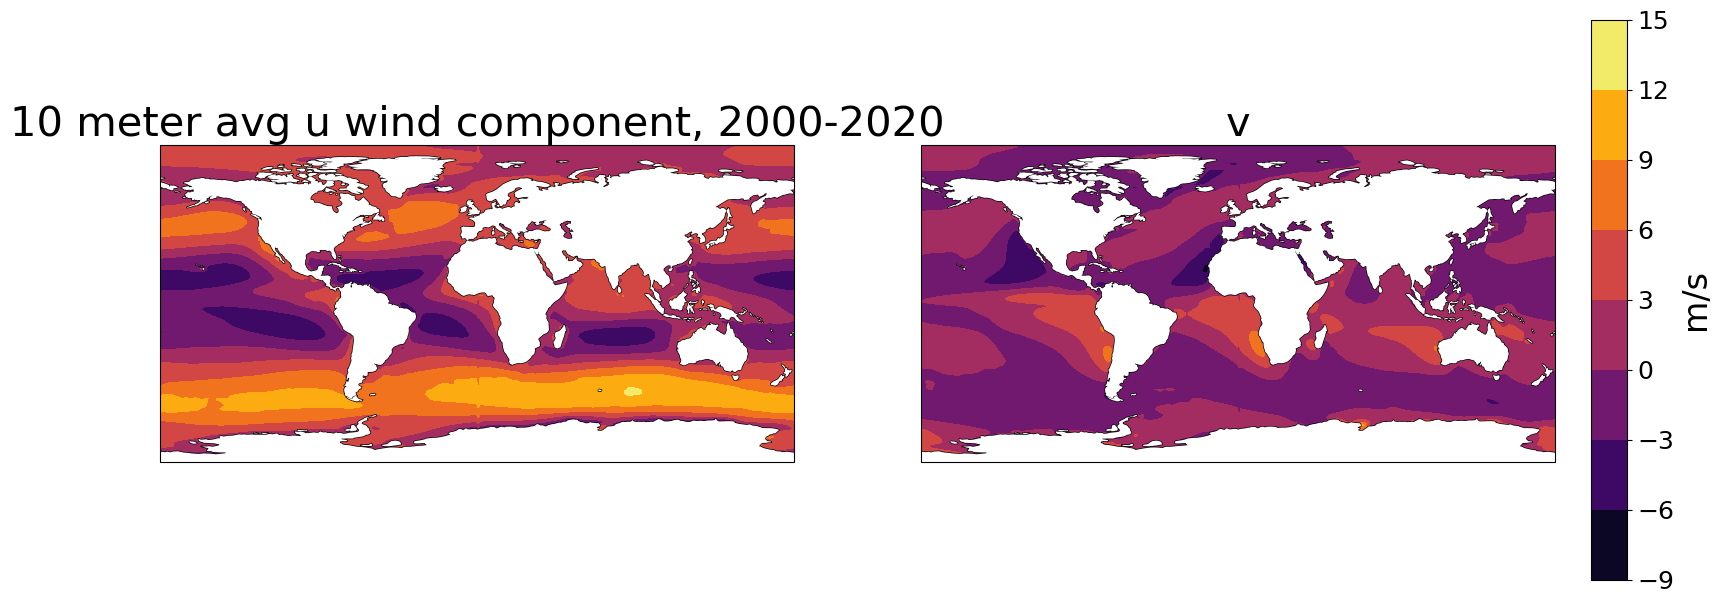

In [35]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8),
                               subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)})

# Plot the u-component of wind
ax1.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
im1 = ax1.contourf(lons, lats, u_winds, cmap='inferno', transform=ccrs.PlateCarree())
ax1.set_title('10 meter avg u wind component, 2000-2020')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')

ax1.coastlines(color = 'black')
land_feature = cfeature.NaturalEarthFeature('physical', 'land', '110m',
                                            edgecolor='none', facecolor='white')
ax1.add_feature(land_feature)

# Plot the v-component of wind
ax2.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
im2 = ax2.contourf(lons, lats, v_winds, cmap='inferno', transform=ccrs.PlateCarree())
ax2.set_title('v')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')

ax2.coastlines(color = 'black')
land_feature = cfeature.NaturalEarthFeature('physical', 'land', '110m',
                                            edgecolor='none', facecolor='white')
ax2.add_feature(land_feature)

# Create a single colorbar for both plots
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(im2, cax=cbar_ax, label='m/s')

# Adjust layout
plt.subplots_adjust(wspace=0.2, right=0.9)  # wspace for width space, right to make space for colorbar

# Show the plot
plt.show()

In [36]:
os.chdir('/home/openonic/global-drifter-program/new')

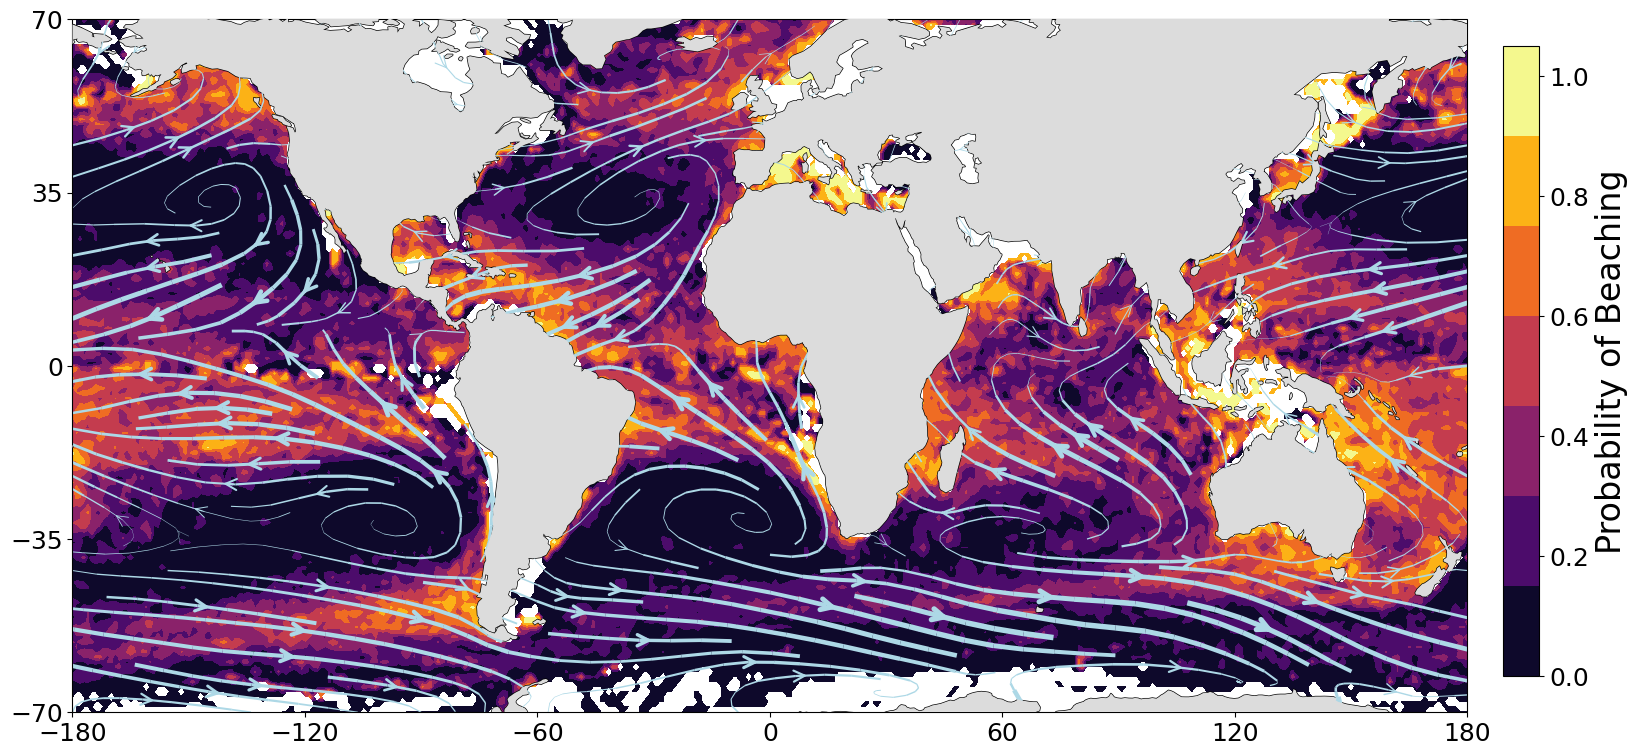

In [37]:
# Load world shapefile
world = gpd.read_file(geodatasets.data.naturalearth.land.path)


# visualize probability of beaching
fig, (ax1) = plt.subplots(1, 1, figsize=(18, 9),
                          subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)})

ax1.set_xticks([-180, -120, -60, 0, 60, 120, 180])
ax1.set_yticks([-70, -35, 0, 35, 70])


cmap = plt.get_cmap('inferno').copy()
ax1.set_extent([-180, 180, -70, 70], crs=ccrs.PlateCarree())
im1 = ax1.contourf(lons, lats, beach_prob_vals_filtered, cmap=cmap, transform=ccrs.PlateCarree(), 
                   vmin=0, vmax=1.0, levels = 6)


#ax1.set_title('Probability of Beaching')
#ax1.set_xlabel('Longitude')
#ax1.set_ylabel('Latitude')



# Create a colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im1, cax=cbar_ax, label='Probability of Beaching')
cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
im1.set_clim(0, 1.0)  # This sets the color limits for the ScalarMappable


# Plot wind vectors
linewidth = 7.5 * np.sqrt(u_winds.values**2 + v_winds.values**2) / np.sqrt(np.nanmax(u_winds.values)**2 + np.nanmax(v_winds.values)**2)
wind_q_global = ax1.streamplot(lons, lats, u_winds.values, v_winds.values, color='lightblue', 
                               linewidth=linewidth, density = 1.5, arrowsize = 2, arrowstyle = '->', zorder=2)

world.plot(ax=ax1, color='gainsboro', edgecolor='none', zorder=3)
ax1.set_aspect('auto')
ax1.coastlines(color = 'black')
#plt.savefig('prob_beach_winds.png', dpi=300)

# Show the plot
plt.show()

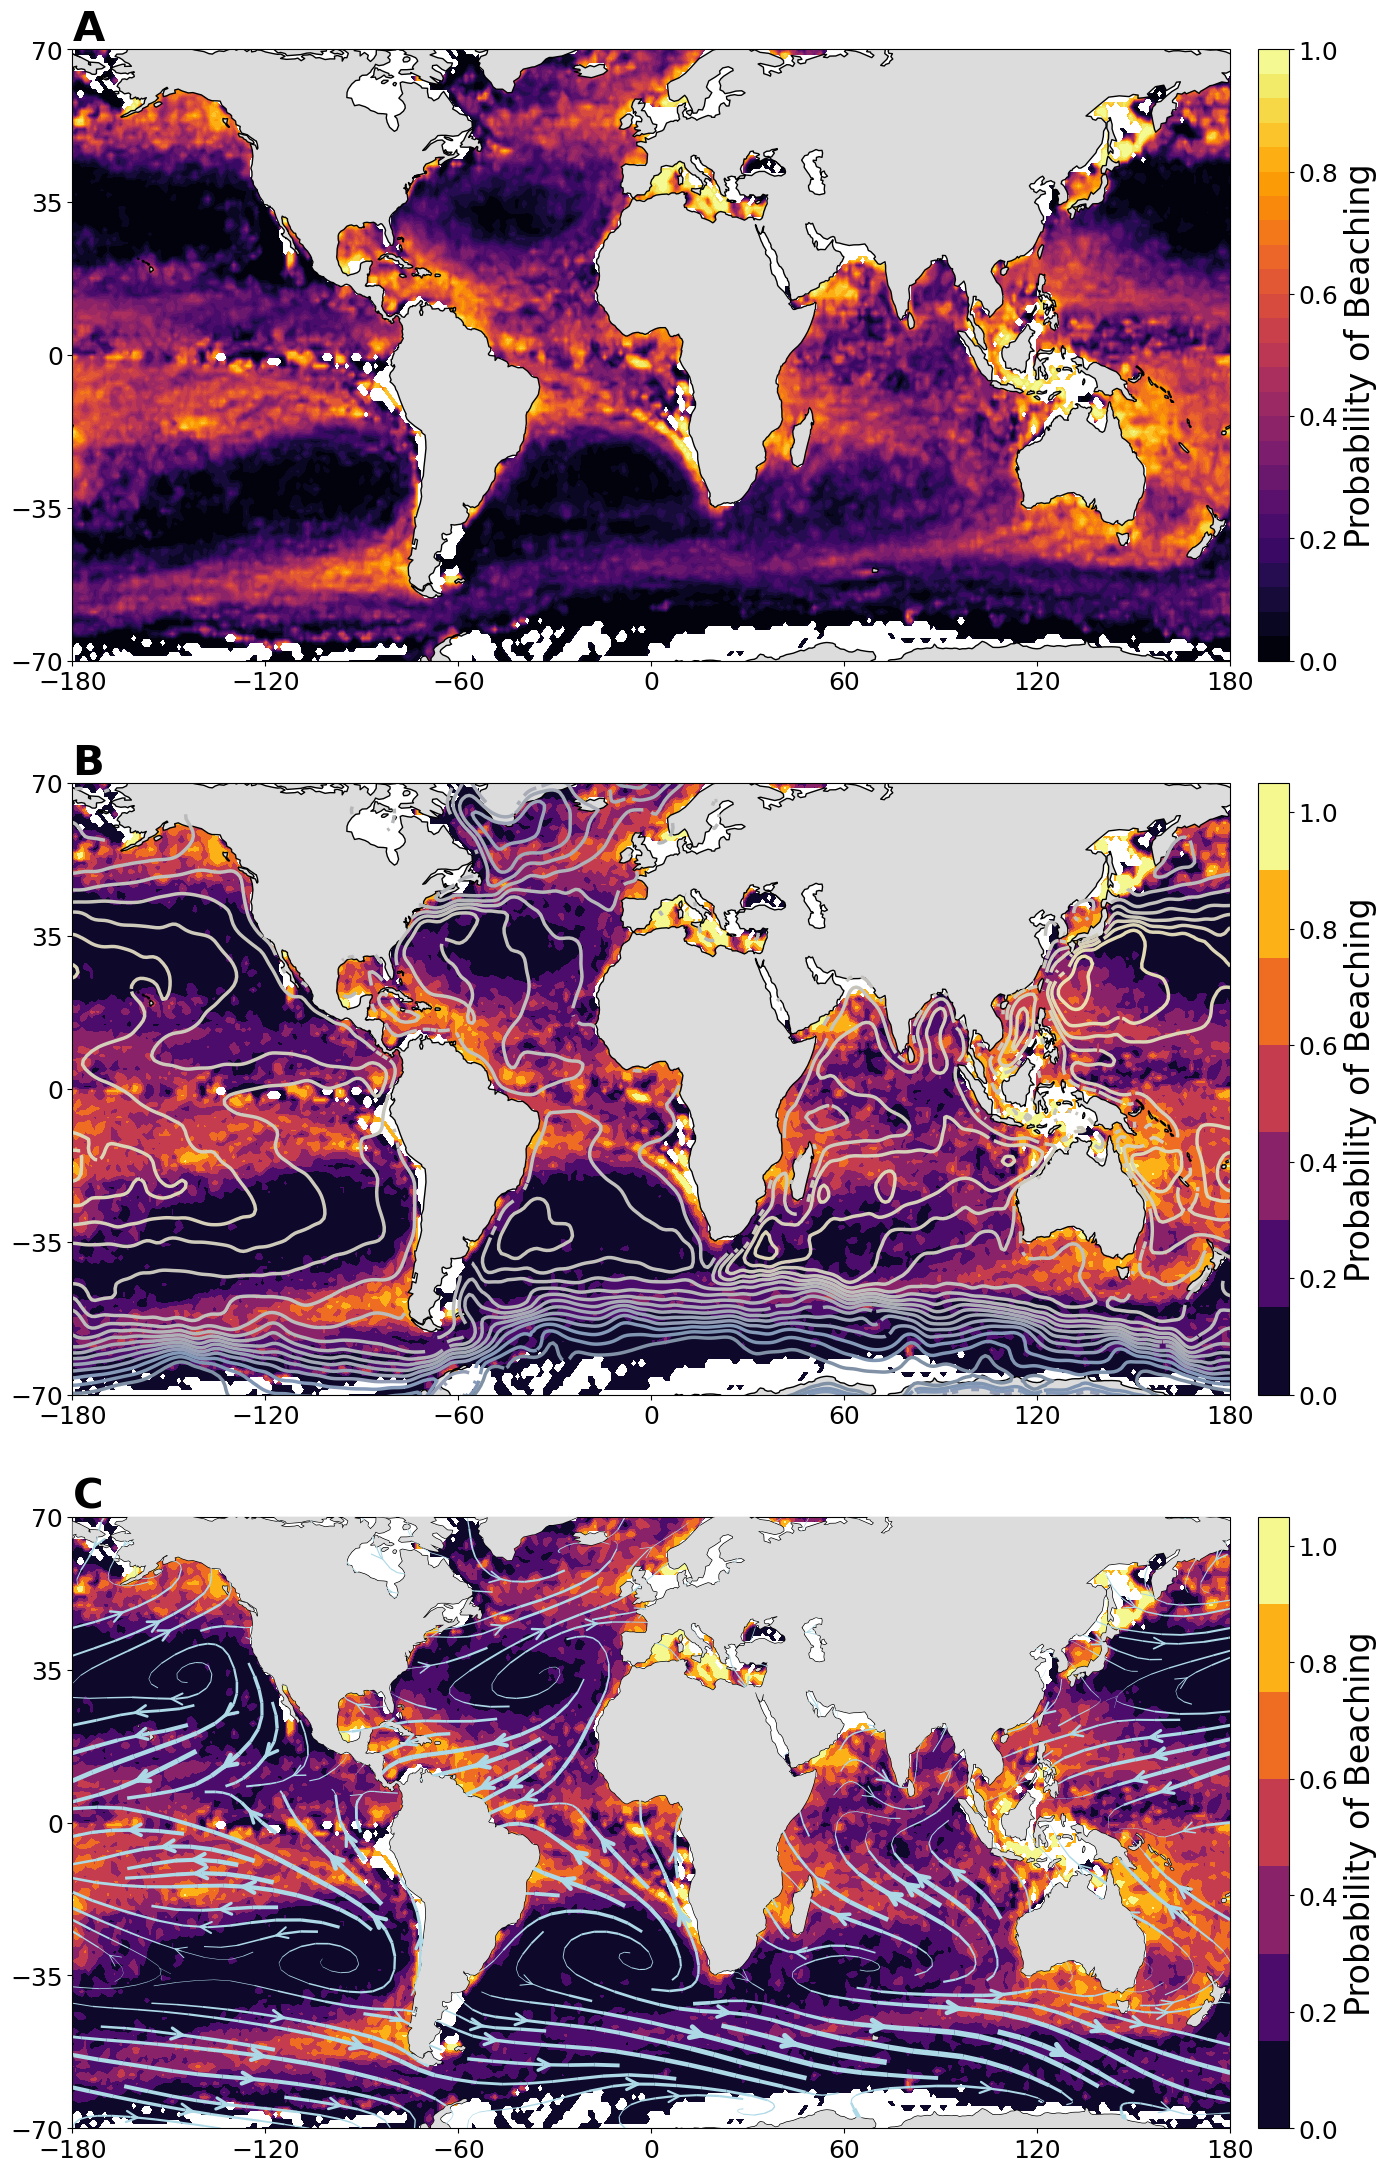

In [38]:
# Load world shapefile
world = gpd.read_file(geodatasets.data.naturalearth.land.path)
#land = world[world['continent'] != 'Antarctica']
#Antarctica = world[world['continent'] == 'Antarctica']

# visualize probability of beaching
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 27),
                                    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)})

for ax in (ax1, ax2, ax3):
    ax.set_xticks([-180, -120, -60, 0, 60, 120, 180])
    ax.set_yticks([-70, -35, 0, 35, 70])
    ax.set_extent([-180, 180, -70, 70], crs=ccrs.PlateCarree())

cmap = plt.get_cmap('inferno').copy()

im1 = ax1.contourf(lons, lats, beach_prob_vals_filtered, cmap=cmap, transform=ccrs.PlateCarree(), 
                   vmin=0, vmax=1.0, levels = 24)

ax1.set_title('A', fontweight='bold', loc='left')
#ax1.set_title('Probability of Beaching')
#ax1.set_xlabel('Longitude')
#ax1.set_ylabel('Latitude')

world.plot(ax=ax1, color='gainsboro', edgecolor='none')
#Antarctica.plot(ax=ax1, color='gainsboro', edgecolor='none')
ax1.set_aspect('auto')

ax1.coastlines(color = 'black')

# Create a colorbar
cbar = fig.colorbar(im1, ax=ax1, orientation='vertical', pad=0.02, label='Probability of Beaching')
cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
im1.set_clim(0, 1.0)  # This sets the color limits for the ScalarMappable

im2 = ax2.contourf(lons, lats, beach_prob_vals_filtered, cmap=cmap, 
                   transform=ccrs.PlateCarree(), vmin=0, vmax=1.0, levels=6)

ax2.set_title('B', fontweight='bold', loc='left')

world.plot(ax=ax2, color='gainsboro', edgecolor='none')

ax2.coastlines(color='black')
ax2.set_aspect('auto')

# colorbar for probability of beaching
cbar = fig.colorbar(im2, ax=ax2, orientation='vertical', pad=0.02, label='Probability of Beaching')
cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
im2.set_clim(0, 1.0)  # Sets the color limits for the ScalarMappable

# plot ssh contours
contour_levels = np.linspace(-1,2,20)#[-0.25, 0, 0.25, 0.5, 0.75, 1, 1.25, 1.5,1.7,1.8]
contour = ax2.contour(lons, lats, adt_stat_filtered.T, levels=contour_levels,
            cmap = lighter_cividis, linewidths = 2.5, vmin = -1, vmax = 2)

im3 = ax3.contourf(lons, lats, beach_prob_vals_filtered, cmap=cmap, transform=ccrs.PlateCarree(), 
                   vmin=0, vmax=1.0, levels = 6)

ax3.set_title('C', fontweight='bold', loc='left')
#ax1.set_title('Probability of Beaching')
#ax1.set_xlabel('Longitude')
#ax1.set_ylabel('Latitude')

# Create a colorbar
cbar = fig.colorbar(im3, ax=ax3, orientation='vertical', pad=0.02, label='Probability of Beaching')
cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
im3.set_clim(0, 1.0)  # This sets the color limits for the ScalarMappable

# Plot wind vectors
linewidth = 7.5 * np.sqrt(u_winds.values**2 + v_winds.values**2) / np.sqrt(np.nanmax(u_winds.values)**2 + np.nanmax(v_winds.values)**2)
wind_q_global = ax3.streamplot(lons, lats, u_winds.values, v_winds.values, color='lightblue', 
                               linewidth=linewidth, density = 1.5, arrowsize = 2, arrowstyle = '->', zorder=2)

world.plot(ax=ax3, color='gainsboro', edgecolor='none', zorder=3)
ax3.set_aspect('auto')
ax3.coastlines(color = 'black')

plt.savefig('figs/probability_of_beaching_subplots.png', dpi=300)

# Show the plot
plt.show()